# Notebook 03 — Rich Data Analysis

**Purpose:** Deep-dive visualisation of the exact 13 features fed into the MLP model.

| # | Feature | Type | Used as |
|---|---------|------|----------|
| 0 | longitude | numeric | raw |
| 1 | latitude | numeric | raw |
| 2 | housing_median_age | numeric | raw |
| 3 | total_rooms | numeric | raw |
| 4 | total_bedrooms | numeric | raw (NaN rows dropped) |
| 5 | population | numeric | raw |
| 6 | households | numeric | raw |
| 7 | median_income | numeric | raw |
| 8-12 | ocean_proximity | categorical → 5 one-hot dummies | one-hot encoded |

**Target:** `median_house_value` divided by 100 000 → range ≈ [0, 5]; hard-capped at 5.0 in the data.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style='whitegrid', font_scale=1.1)
FIG_DPI  = 150
TITLE_FS = 14
LABEL_FS = 12
SCALE    = 100_000.0
CAP_VAL  = 500_000   # hard ceiling in raw USD
plt.rcParams.update({'figure.dpi': FIG_DPI, 'savefig.bbox': 'tight'})

VIZ_DIR = '../../data/visualize'
os.makedirs(VIZ_DIR, exist_ok=True)

# ── Load raw data (pre-preprocessing) ────────────────────────────────────
df_raw = pd.read_csv('../../data/raw/housing.csv')
print(f'Raw shape          : {df_raw.shape}')

df = df_raw.dropna().reset_index(drop=True)
print(f'After dropna       : {df.shape}  ({len(df_raw)-len(df)} rows removed)')

NUMERIC_FEATURES = [
    'longitude','latitude','housing_median_age',
    'total_rooms','total_bedrooms','population',
    'households','median_income'
]
TARGET = 'median_house_value'
df.head(3)

Raw shape          : (20640, 10)
After dropna       : (20433, 10)  (207 rows removed)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


---
### 📊 PLOT 1 — Missing Values Heatmap (Raw Data)
**What it shows:** Which rows/columns have NaN values before cleaning.  
**Presentation use:** Justifies why rows were dropped in preprocessing — only `total_bedrooms` has missing values, affecting ~1% of data.

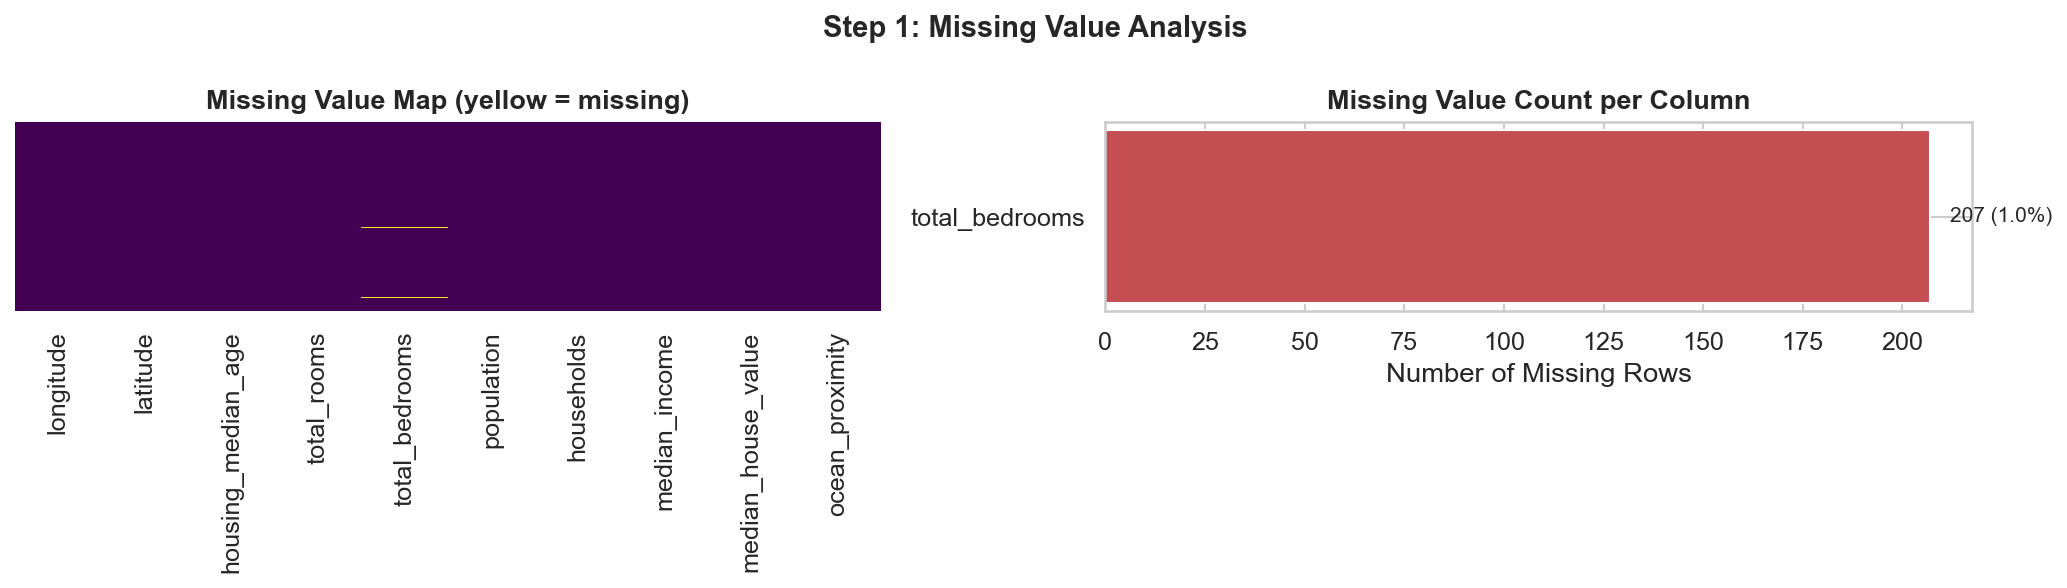

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Value Map (yellow = missing)', fontsize=13, fontweight='bold')

# Bar of missing counts
missing = df_raw.isnull().sum()
missing = missing[missing > 0]
axes[1].barh(missing.index, missing.values, color='#C44E52', edgecolor='white')
for i, v in enumerate(missing.values):
    pct = v / len(df_raw) * 100
    axes[1].text(v + 5, i, f'{v} ({pct:.1f}%)', va='center', fontsize=10)
axes[1].set_title('Missing Value Count per Column', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Missing Rows')

fig.suptitle('Step 1: Missing Value Analysis', fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_01_missing_values.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 2 — Target Distribution: Raw vs Scaled
**What it shows:** Histogram of house values before and after the /100 000 scaling applied in preprocessing.  
**Presentation use:** Shows why scaling was needed; also reveals the **hard cap at $500K (= 5.0 scaled)** which is a known source of prediction bias.

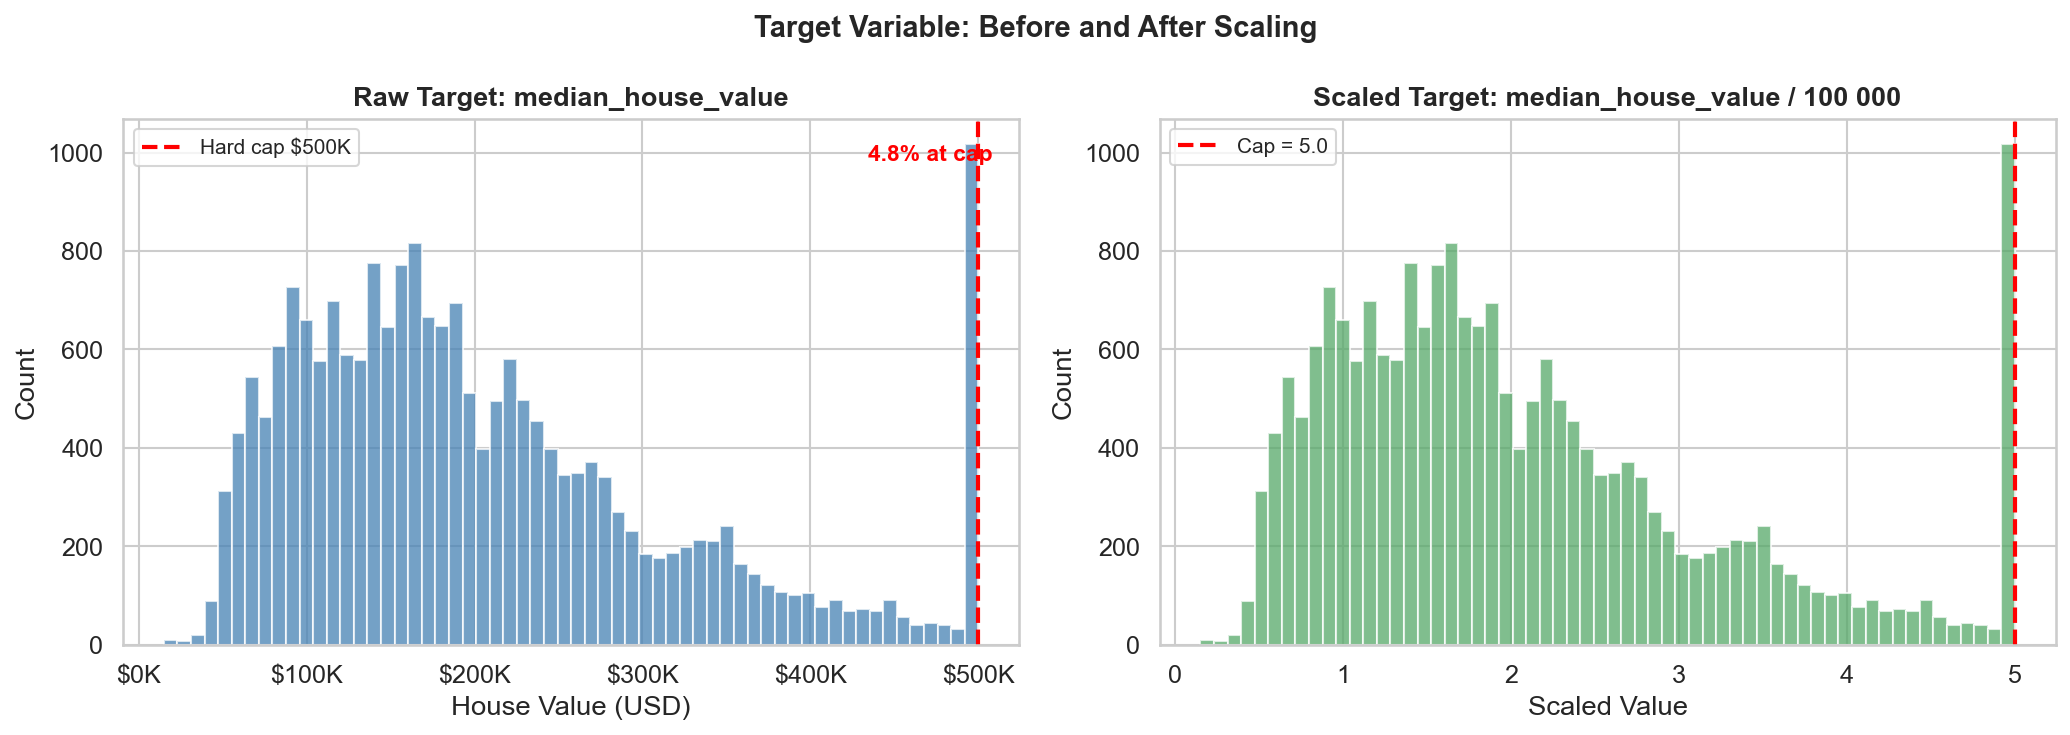

Rows at/above $500K cap: 985 (4.82%)
Target stats (scaled): min=0.150  max=5.000  mean=2.069


In [17]:
y_raw    = df[TARGET]
y_scaled = y_raw / SCALE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw
axes[0].hist(y_raw, bins=60, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].axvline(CAP_VAL, color='red', linestyle='--', linewidth=2, label=f'Hard cap ${CAP_VAL/1e3:.0f}K')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].set_title('Raw Target: median_house_value', fontsize=13, fontweight='bold')
axes[0].set_xlabel('House Value (USD)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=10)
capped_pct = (y_raw >= CAP_VAL).mean() * 100
axes[0].text(0.97, 0.95, f'{capped_pct:.1f}% at cap',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=11, color='red', fontweight='bold')

# Scaled
axes[1].hist(y_scaled, bins=60, color='#55A868', alpha=0.75, edgecolor='white')
axes[1].axvline(5.0, color='red', linestyle='--', linewidth=2, label='Cap = 5.0')
axes[1].set_title('Scaled Target: median_house_value / 100 000', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Scaled Value')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=10)

fig.suptitle('Target Variable: Before and After Scaling', fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_02_target_distribution.png', dpi=FIG_DPI)
plt.show()

print(f"Rows at/above ${CAP_VAL/1e3:.0f}K cap: {(y_raw >= CAP_VAL).sum()} ({capped_pct:.2f}%)")
print(f"Target stats (scaled): min={y_scaled.min():.3f}  max={y_scaled.max():.3f}  mean={y_scaled.mean():.3f}")

---
### 📊 PLOT 3 — Individual Distribution of All 8 Numeric Features
**What it shows:** Histogram + KDE for every numeric feature fed into the model.  
**Presentation use:** Shows right-skew in count-based features (total_rooms, population, households) — explains why StandardScaler was necessary.

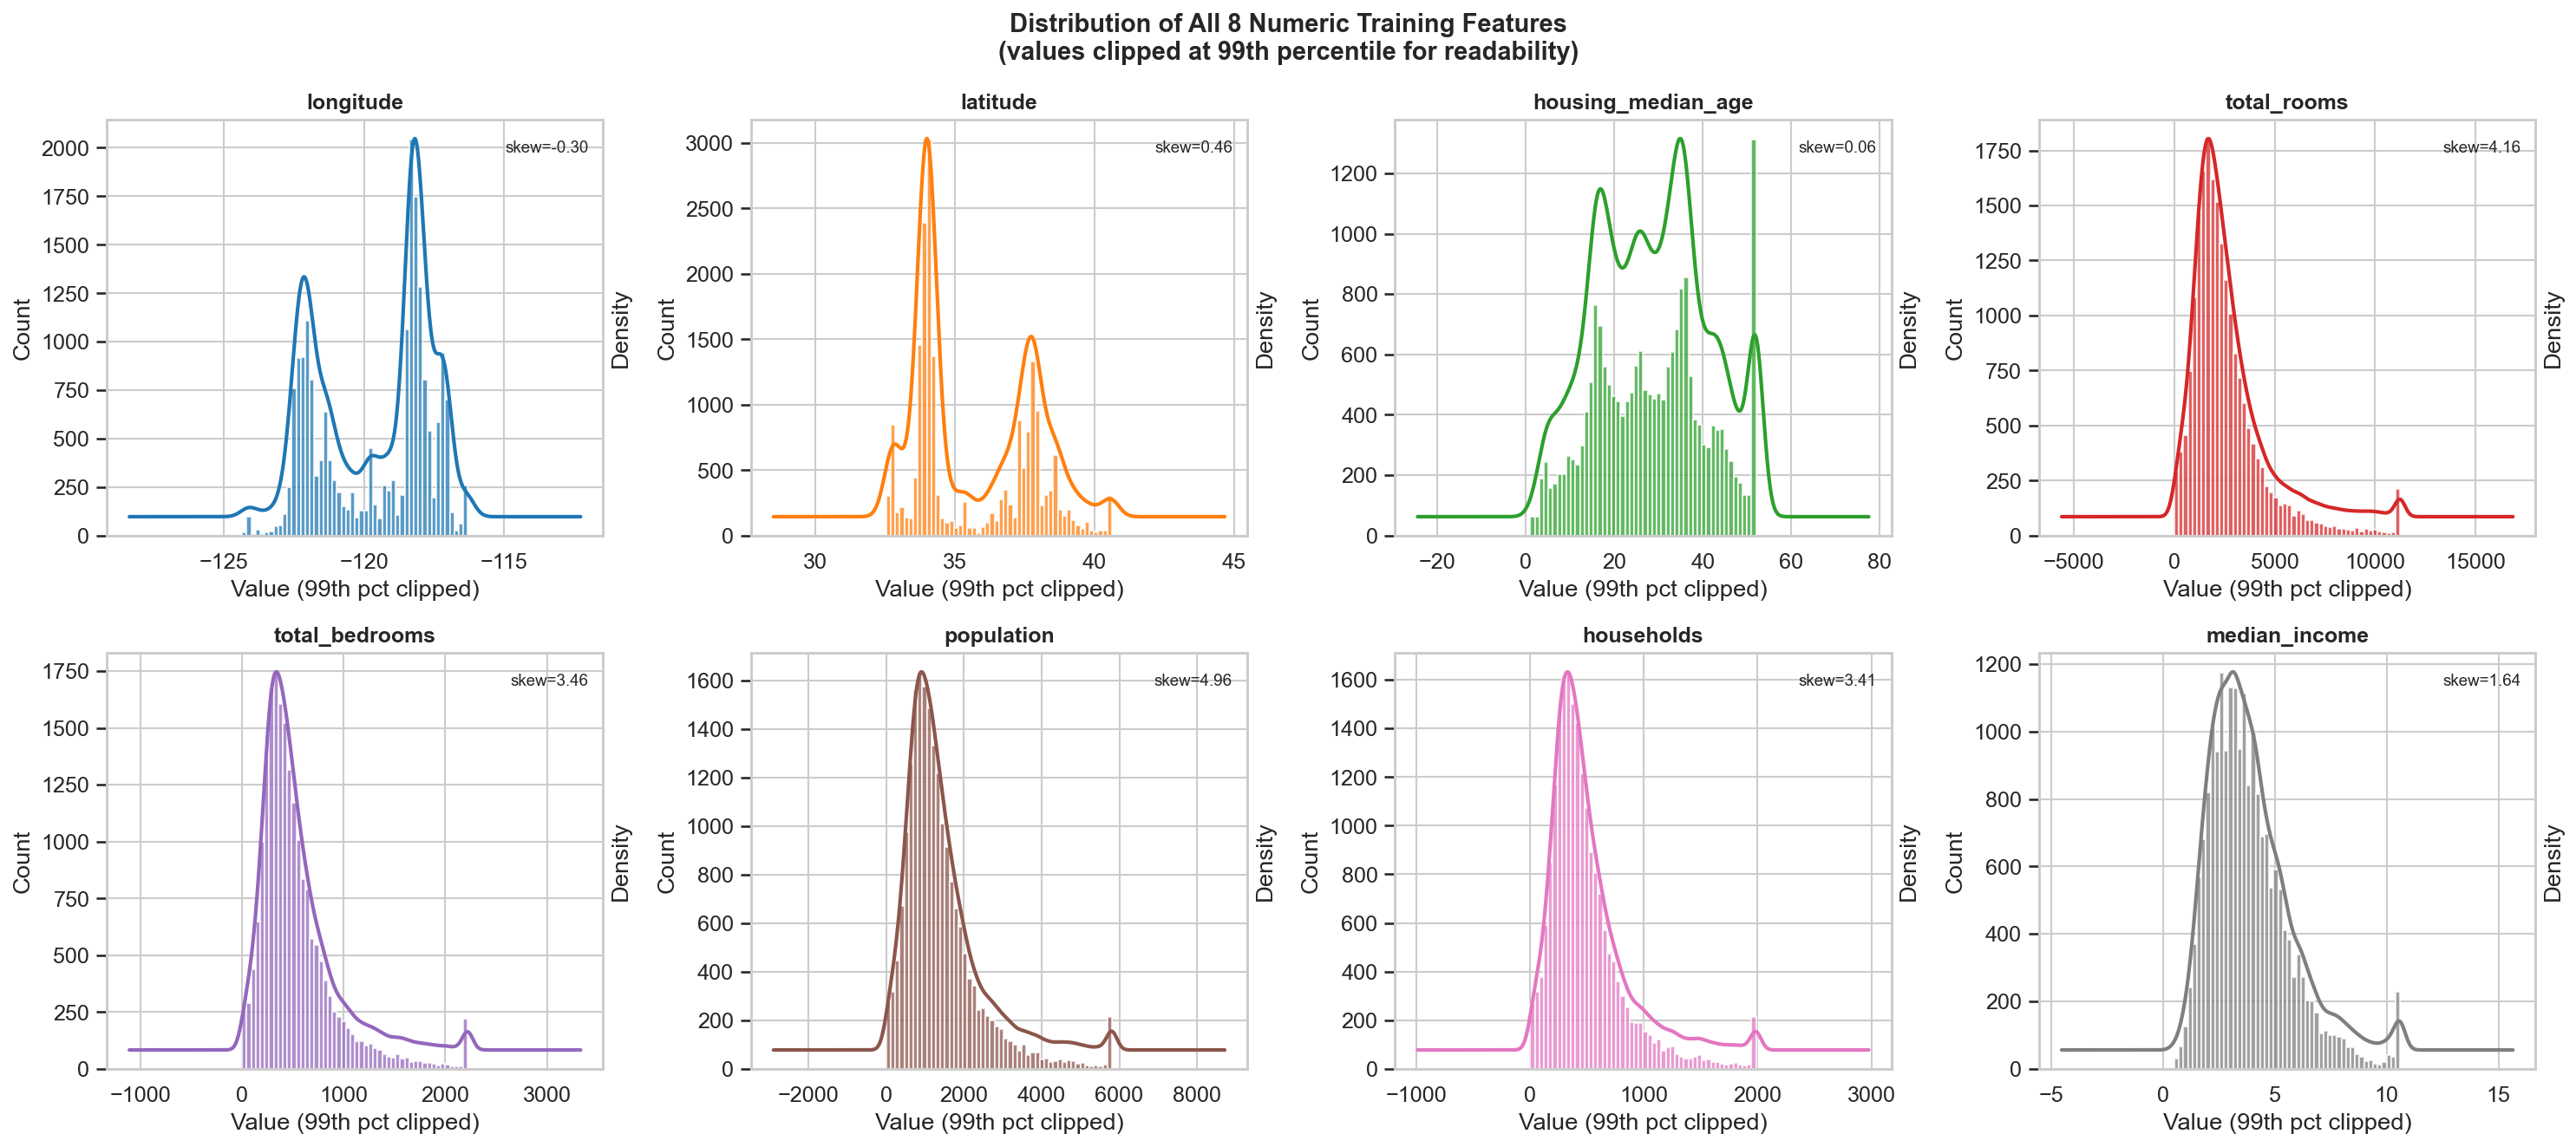

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
colors = sns.color_palette('tab10', 8)

for ax, col, c in zip(axes.flat, NUMERIC_FEATURES, colors):
    clipped = df[col].clip(upper=df[col].quantile(0.99))
    ax.hist(clipped, bins=50, color=c, alpha=0.75, edgecolor='white', density=False)
    ax2 = ax.twinx()
    clipped.plot.kde(ax=ax2, color=c, linewidth=2)
    ax2.set_yticks([])
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value (99th pct clipped)')
    ax.set_ylabel('Count')
    # Annotate skewness
    sk = df[col].skew()
    ax.text(0.97, 0.95, f'skew={sk:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

fig.suptitle('Distribution of All 8 Numeric Training Features\n(values clipped at 99th percentile for readability)',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_03_feature_distributions.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 4 — Before vs After StandardScaler (Side-by-Side)
**What it shows:** Mean and std of each feature before and after StandardScaler normalisation.  
**Presentation use:** Explains what preprocessing does — all features brought to mean≈0, std≈1 so no single feature dominates gradient updates.

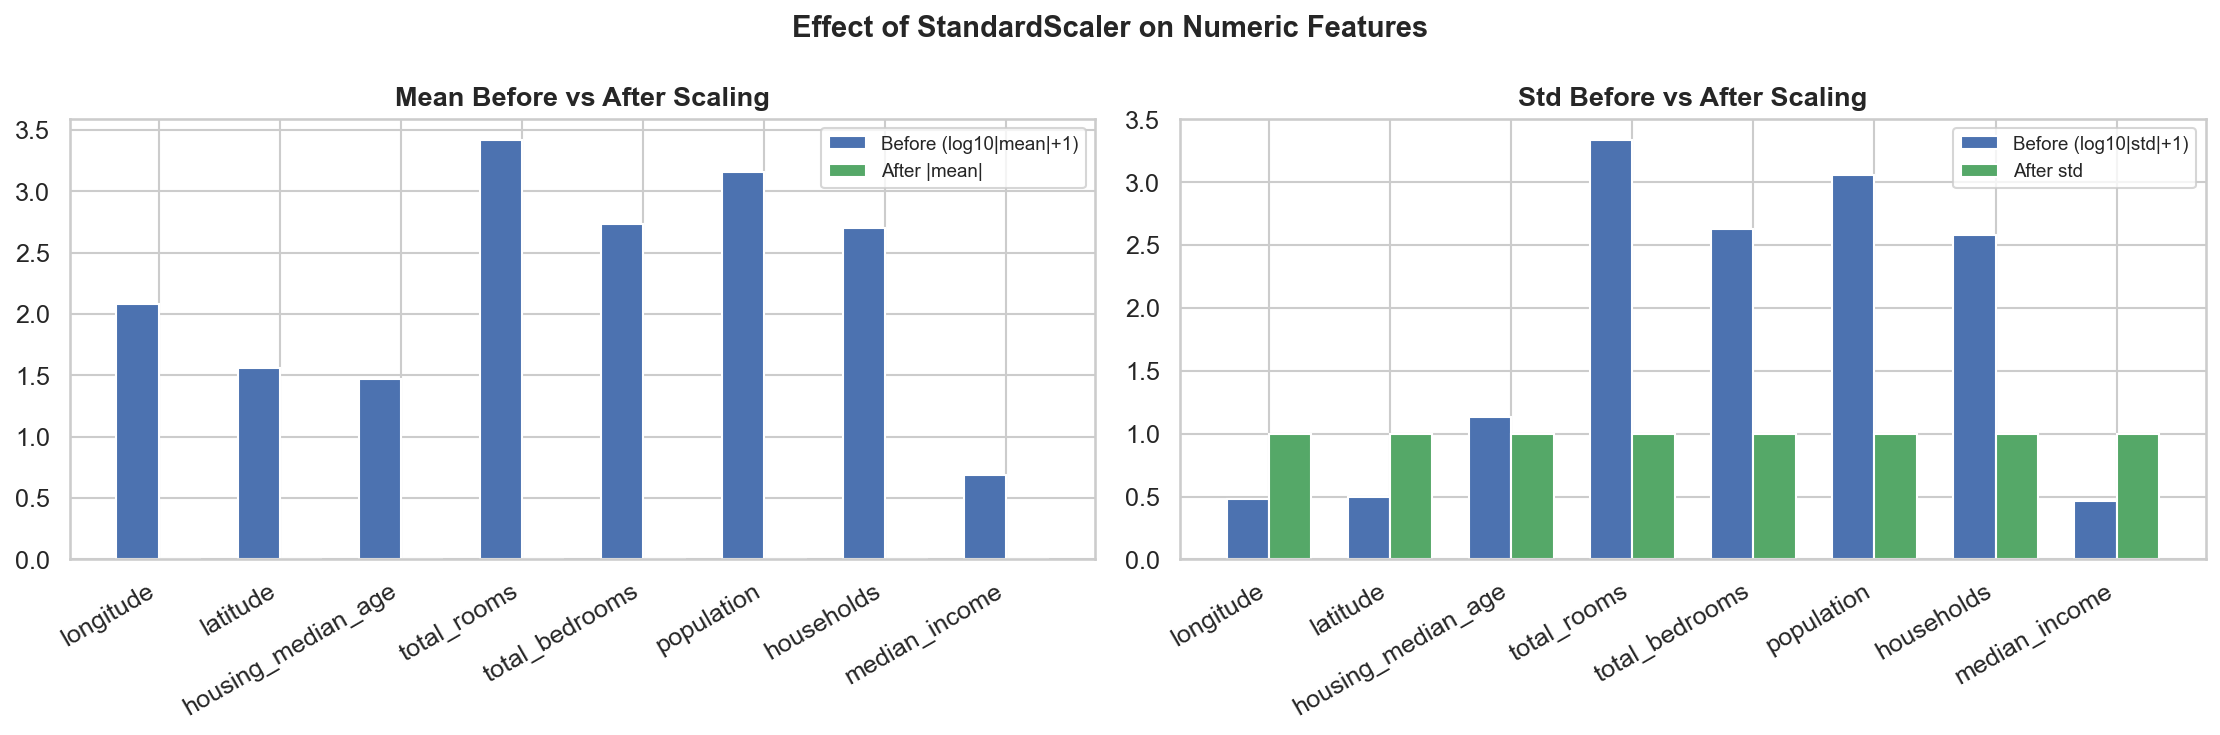

In [19]:
from sklearn.preprocessing import StandardScaler

X_raw = df[NUMERIC_FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

raw_means  = df[NUMERIC_FEATURES].mean()
raw_stds   = df[NUMERIC_FEATURES].std()
sc_means   = pd.Series(X_scaled.mean(axis=0), index=NUMERIC_FEATURES)
sc_stds    = pd.Series(X_scaled.std(axis=0),  index=NUMERIC_FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(NUMERIC_FEATURES))
width = 0.35

# Mean comparison (log scale because raw means vary by orders of magnitude)
axes[0].bar(x - width/2, np.log10(np.abs(raw_means) + 1), width,
            label='Before (log10|mean|+1)', color='#4C72B0', edgecolor='white')
axes[0].bar(x + width/2, np.abs(sc_means), width,
            label='After |mean|', color='#55A868', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(NUMERIC_FEATURES, rotation=30, ha='right')
axes[0].set_title('Mean Before vs After Scaling', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# Std comparison
axes[1].bar(x - width/2, np.log10(raw_stds + 1), width,
            label='Before (log10|std|+1)', color='#4C72B0', edgecolor='white')
axes[1].bar(x + width/2, sc_stds, width,
            label='After std', color='#55A868', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(NUMERIC_FEATURES, rotation=30, ha='right')
axes[1].set_title('Std Before vs After Scaling', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

fig.suptitle('Effect of StandardScaler on Numeric Features', fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_04_scaler_effect.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 5 — Correlation Matrix (8 Numeric Features + Target)
**What it shows:** Pearson correlations among the exact features the model sees.  
**Presentation use:** `median_income` has the strongest positive correlation with price (~0.69); high collinearity between `total_rooms`, `total_bedrooms`, `population`, `households` signals redundancy.

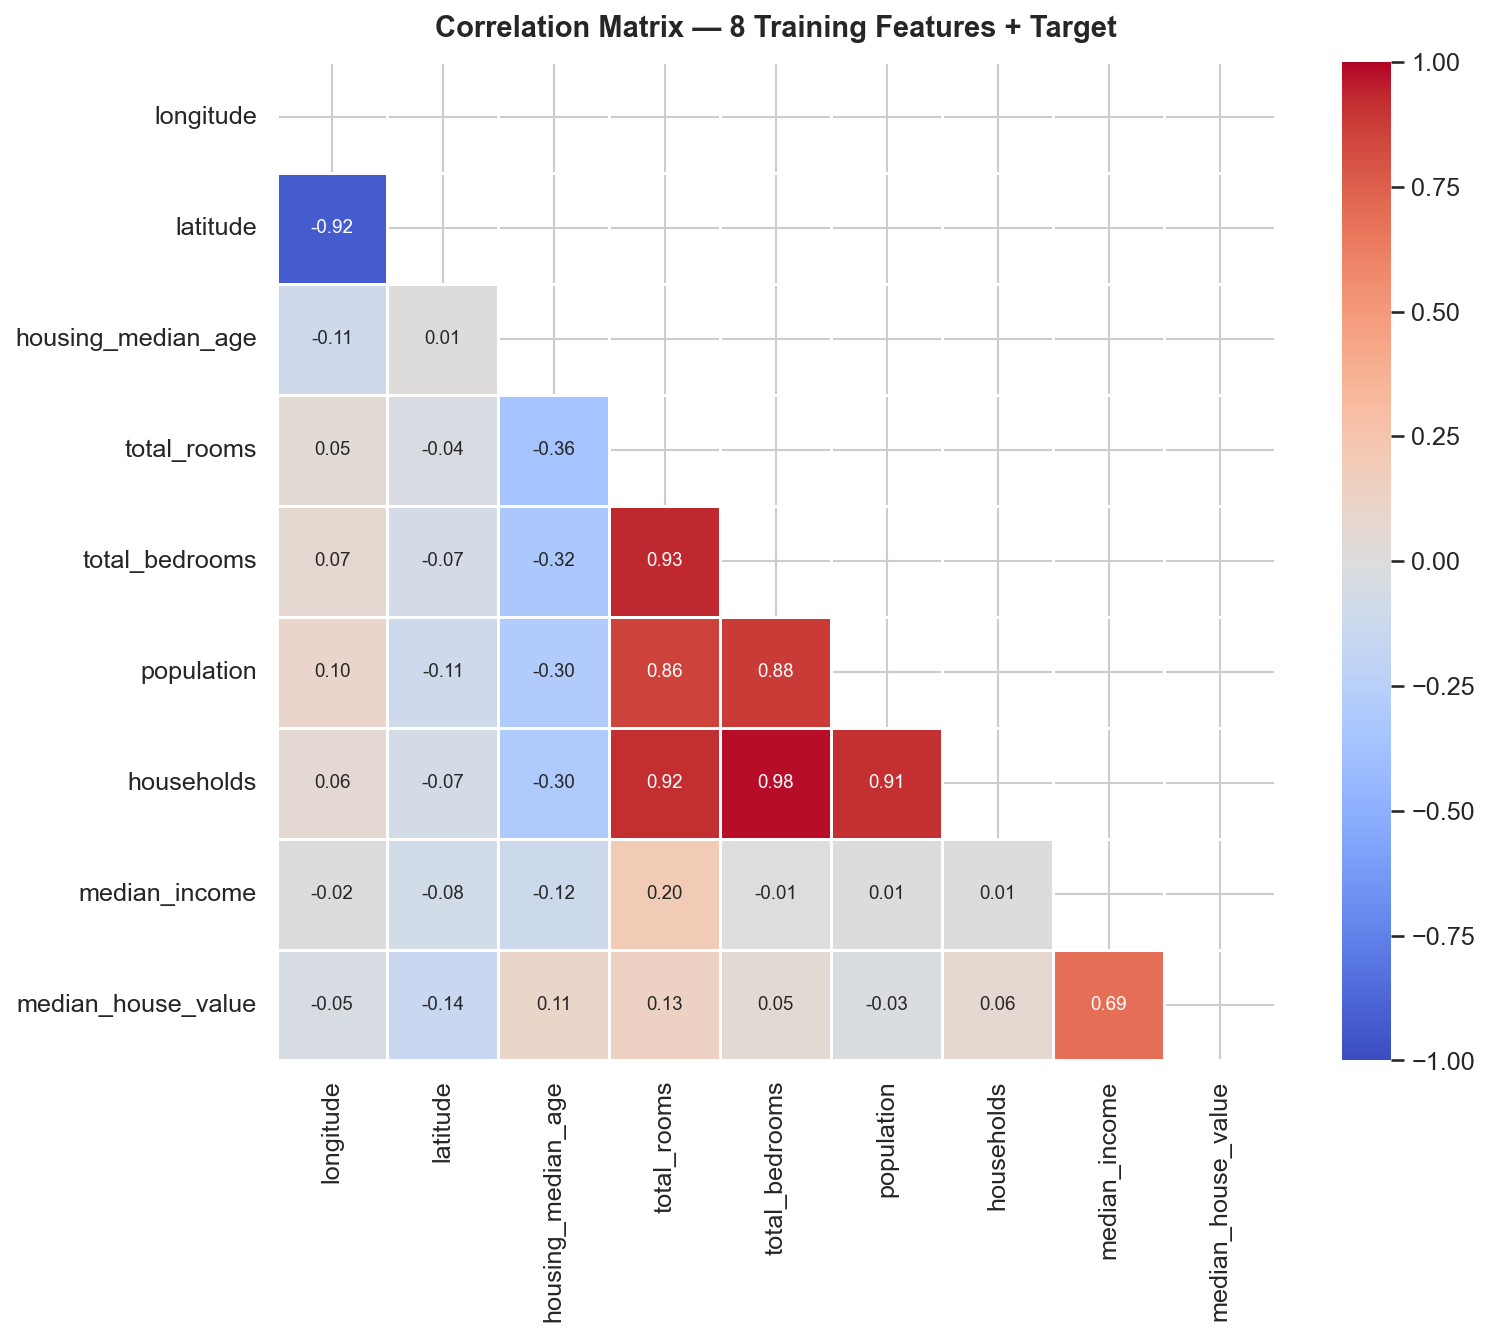

In [20]:
corr_cols = NUMERIC_FEATURES + [TARGET]
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Correlation Matrix — 8 Training Features + Target',
             fontsize=TITLE_FS, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_05_correlation_matrix.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 6 — Feature Correlations with Target (Ranked Bar)
**What it shows:** Sorted bar showing each feature's Pearson r with `median_house_value`.  
**Presentation use:** Clean one-slide summary — `median_income` dominates; latitude/longitude provide geographic signal; count-based features are weakly correlated.

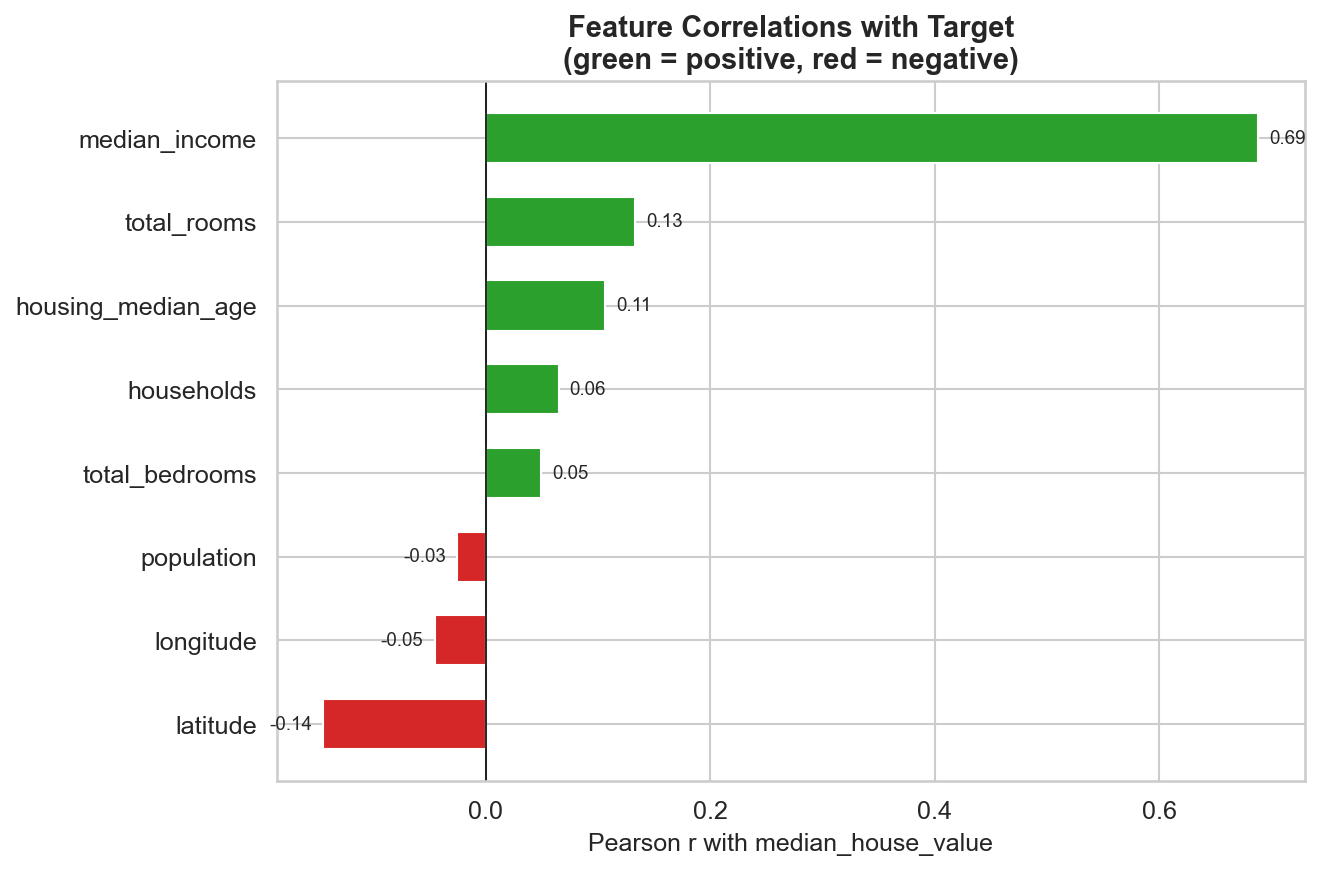

In [21]:
target_corr = corr[TARGET].drop(TARGET).sort_values()
bar_colors  = ['#d62728' if v < 0 else '#2ca02c' for v in target_corr]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(target_corr.index, target_corr.values,
               color=bar_colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with median_house_value', fontsize=LABEL_FS)
ax.set_title('Feature Correlations with Target\n(green = positive, red = negative)',
             fontsize=TITLE_FS, fontweight='bold')
for bar, val in zip(bars, target_corr.values):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_06_target_correlations.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 7 — Scatter of Each Feature vs Target
**What it shows:** 8 scatter plots, one per numeric feature against `median_house_value`.  
**Presentation use:** Shows which features have a clear linear signal vs noisy relationship; the $500K horizontal band is clearly visible in every plot.

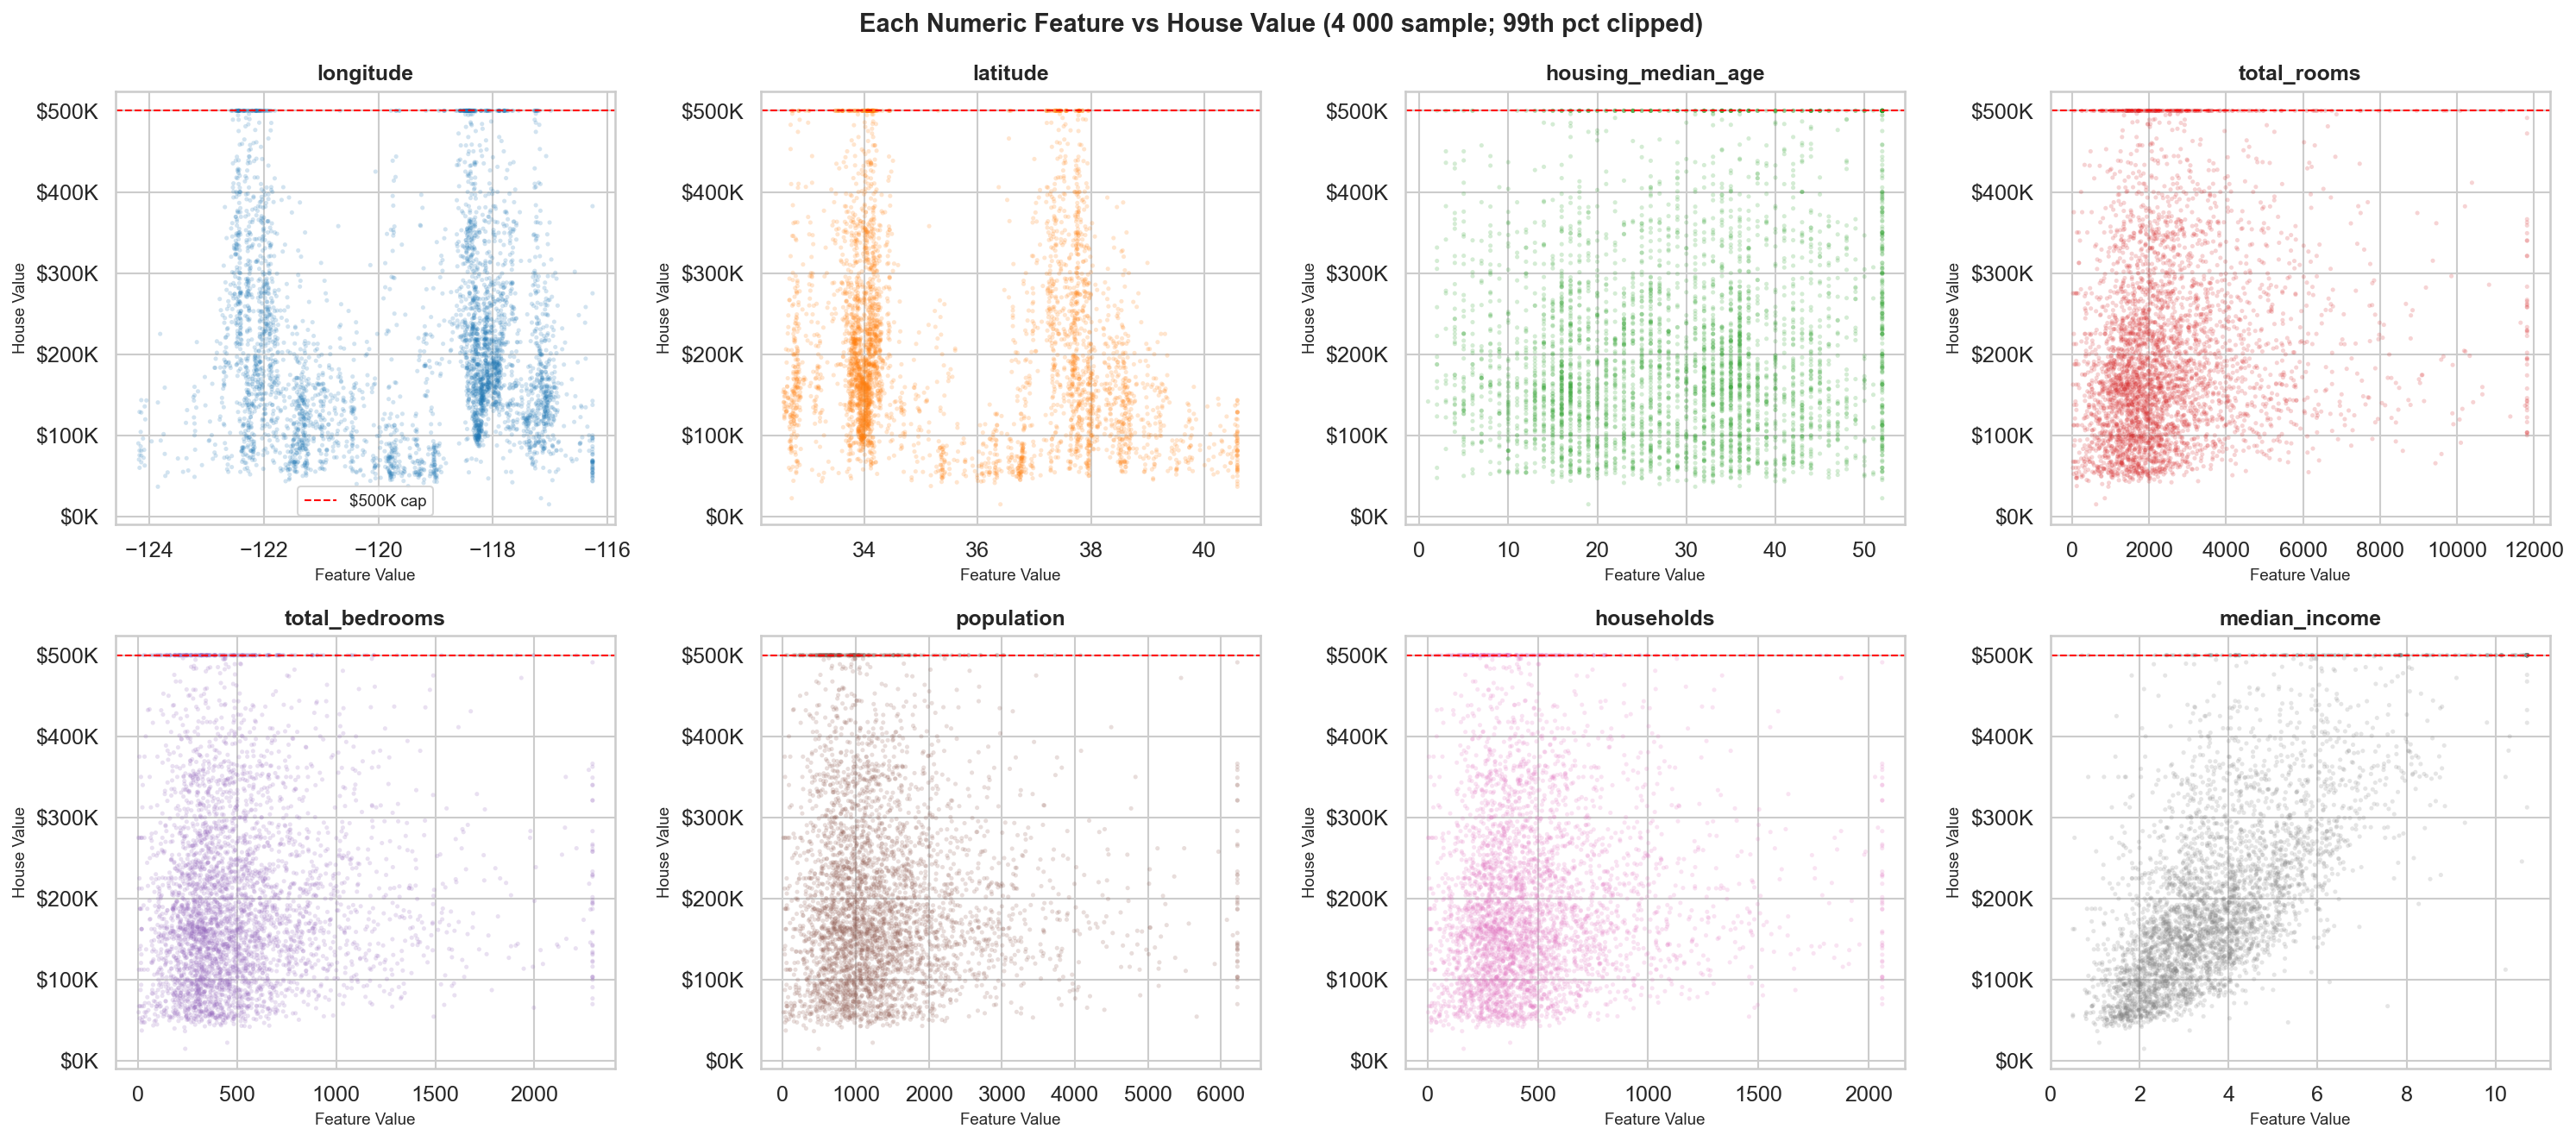

In [22]:
sample = df.sample(4000, random_state=42)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
colors = sns.color_palette('tab10', 8)

for ax, col, c in zip(axes.flat, NUMERIC_FEATURES, colors):
    x_clip = sample[col].clip(upper=sample[col].quantile(0.99))
    ax.scatter(x_clip, sample[TARGET], alpha=0.2, s=6, color=c, edgecolors='none')
    ax.axhline(CAP_VAL, color='red', linestyle='--', linewidth=1,
               label='$500K cap' if col == NUMERIC_FEATURES[0] else '')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Value', fontsize=9)
    ax.set_ylabel('House Value', fontsize=9)

axes[0, 0].legend(fontsize=9)
fig.suptitle('Each Numeric Feature vs House Value (4 000 sample; 99th pct clipped)',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_07_feature_vs_target_scatter.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 8 — Median Income vs House Value (Hexbin Density)
**What it shows:** Density hexbin of the single strongest predictor vs target.  
**Presentation use:** With 20 000+ points, hexbin is cleaner than scatter; the strong band and hard $500K ceiling are unmistakable.

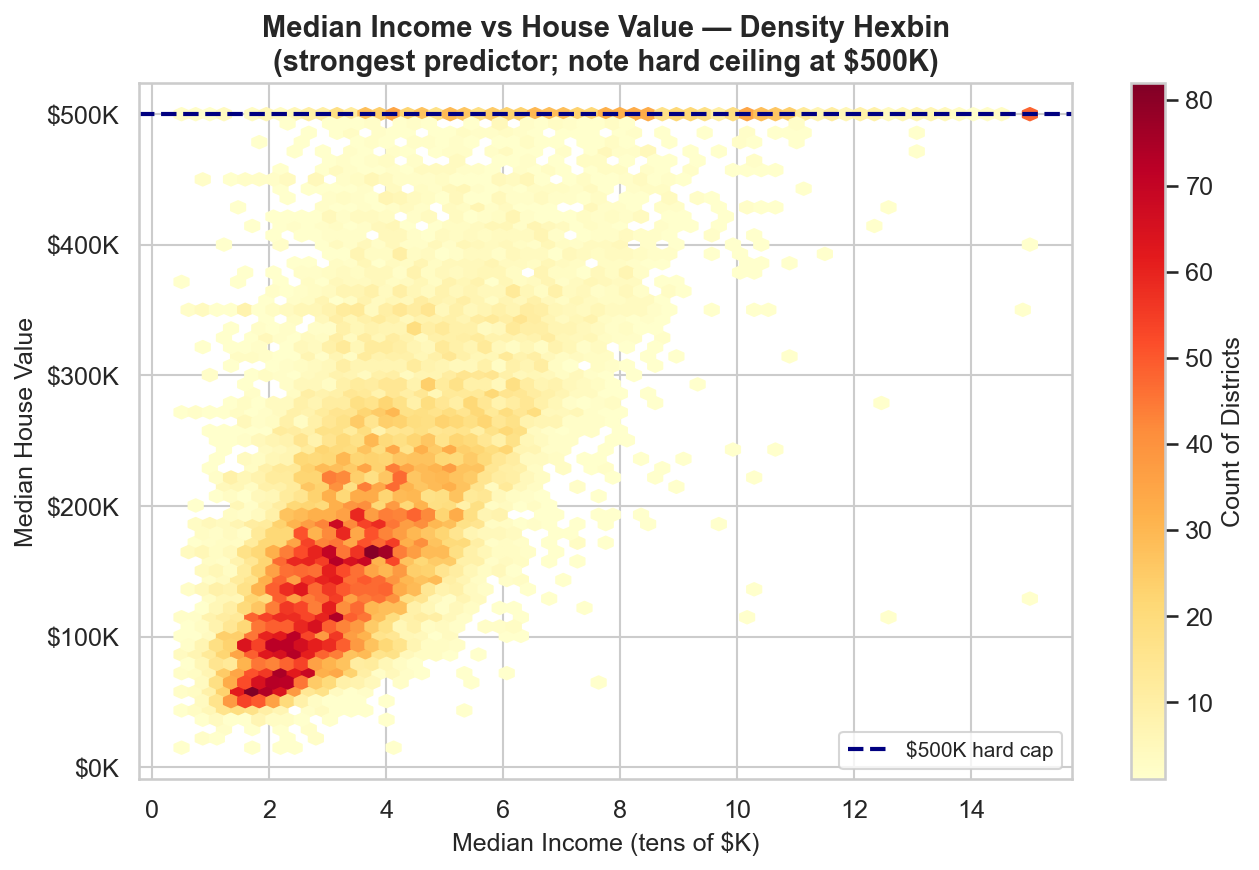

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
hb = ax.hexbin(df['median_income'], df[TARGET],
               gridsize=60, cmap='YlOrRd', mincnt=1)
cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Count of Districts', fontsize=LABEL_FS)
ax.axhline(CAP_VAL, color='navy', linestyle='--', linewidth=2, label=f'$500K hard cap')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Median Income (tens of $K)', fontsize=LABEL_FS)
ax.set_ylabel('Median House Value', fontsize=LABEL_FS)
ax.set_title('Median Income vs House Value — Density Hexbin\n'
             '(strongest predictor; note hard ceiling at $500K)',
             fontsize=TITLE_FS, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_08_hexbin_income_value.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 9 — Ocean Proximity: Count + Price Distribution
**What it shows:** Bar of district counts per category and box of house value per category.  
**Presentation use:** Shows class imbalance among the 5 one-hot columns (INLAND dominates); and that each category has a distinct price profile the model must learn.

C:\Users\TDV\AppData\Local\Temp\ipykernel_9136\184095572.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


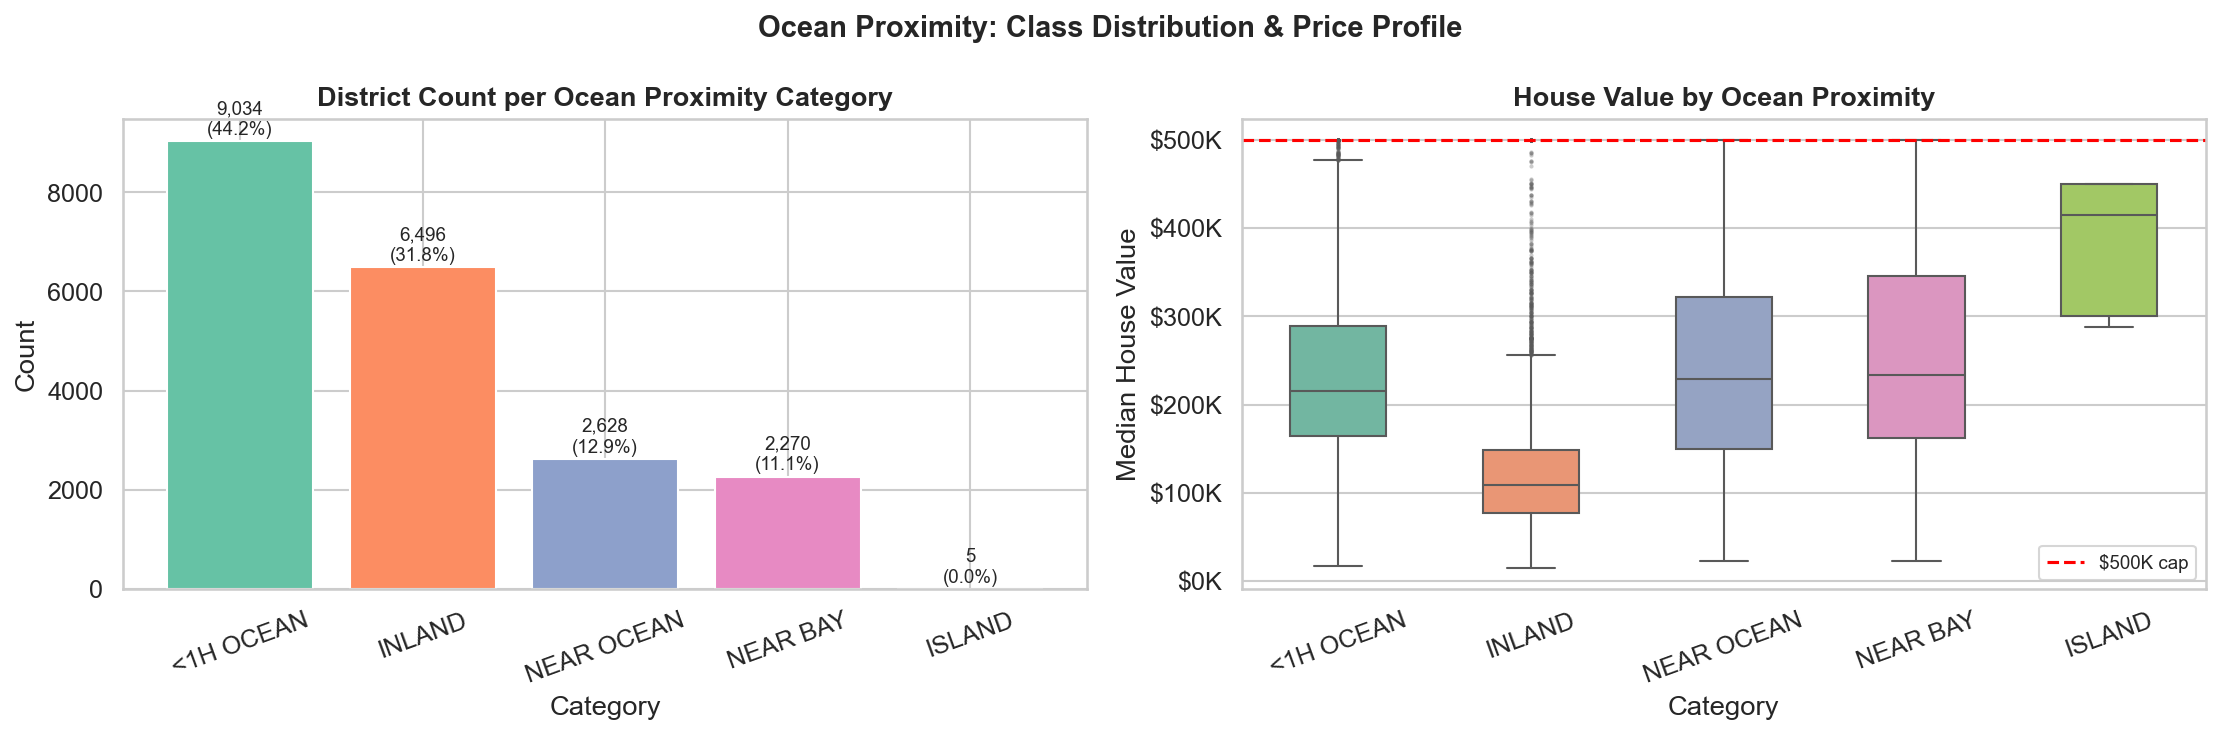

Mean house value per category:
ocean_proximity
ISLAND        $380,440
NEAR BAY      $259,279
NEAR OCEAN    $249,042
<1H OCEAN     $240,268
INLAND        $124,897
Name: median_house_value, dtype: str


In [24]:
prox_order = df['ocean_proximity'].value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count bar
counts = df['ocean_proximity'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=sns.color_palette('Set2', len(counts)),
                   edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('District Count per Ocean Proximity Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

# Price boxplot
sns.boxplot(
    data=df, x='ocean_proximity', y=TARGET,
    order=prox_order, palette='Set2', ax=axes[1], width=0.5,
    flierprops=dict(marker='.', markersize=2, alpha=0.3)
)
axes[1].axhline(CAP_VAL, color='red', linestyle='--', linewidth=1.5, label='$500K cap')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_title('House Value by Ocean Proximity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Median House Value')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=9)

fig.suptitle('Ocean Proximity: Class Distribution & Price Profile',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_09_ocean_proximity.png', dpi=FIG_DPI)
plt.show()

# Mean price per category
print('Mean house value per category:')
print(df.groupby('ocean_proximity')[TARGET].mean().sort_values(ascending=False)
        .apply(lambda x: f'${x:,.0f}'))

---
### 📊 PLOT 10 — One-Hot Encoded Features: Mean House Value
**What it shows:** After one-hot encoding, the mean target for each dummy variable when it equals 1.  
**Presentation use:** Shows what the model 'sees' — the 5 binary columns each carry a very different average price signal.

One-hot columns (indices 8-12 in X): ['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


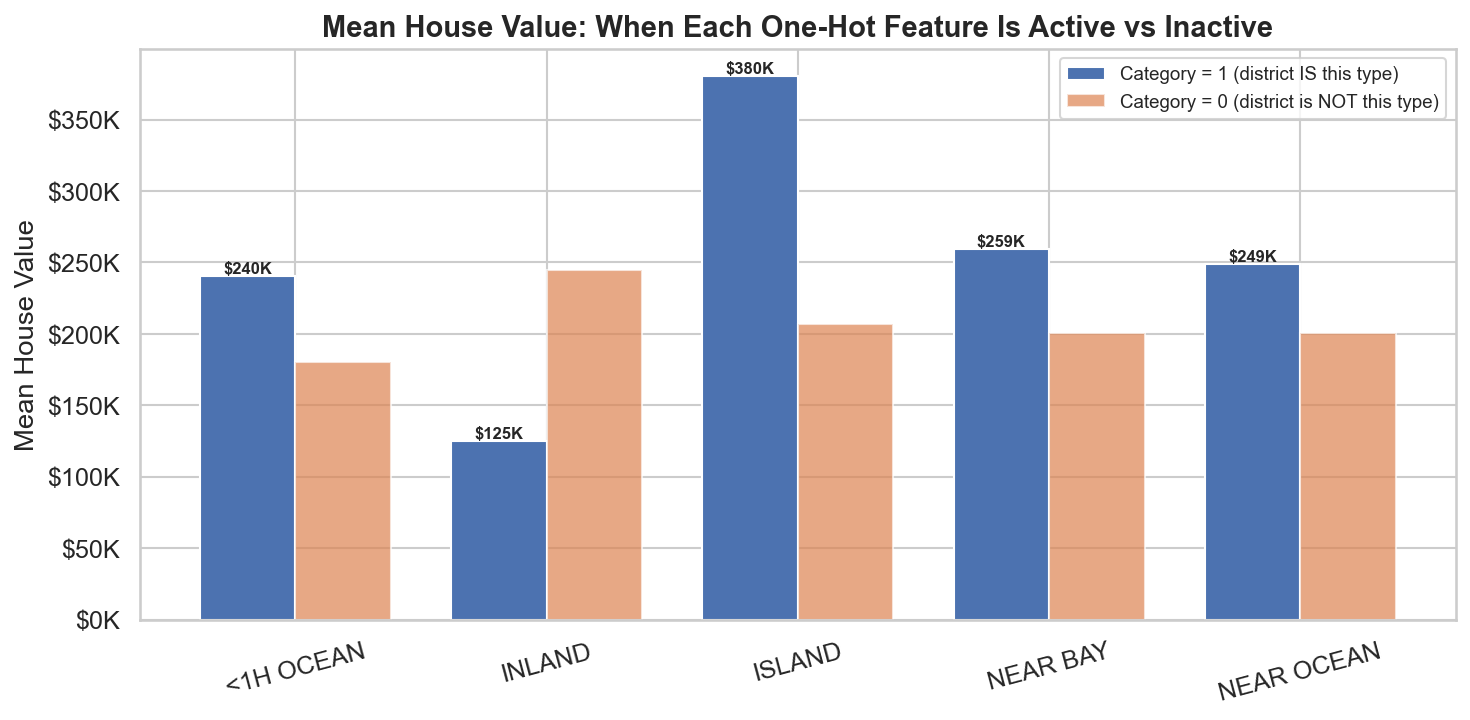

In [25]:
dummies = pd.get_dummies(df[['ocean_proximity']], dtype=float)
dummy_cols = dummies.columns.tolist()
print('One-hot columns (indices 8-12 in X):', dummy_cols)

df_ohe = pd.concat([df[TARGET], dummies], axis=1)

means_1 = {col: df_ohe.loc[df_ohe[col] == 1.0, TARGET].mean() for col in dummy_cols}
means_0 = {col: df_ohe.loc[df_ohe[col] == 0.0, TARGET].mean() for col in dummy_cols}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(dummy_cols))
width = 0.38

bars1 = ax.bar(x - width/2, [means_1[c] for c in dummy_cols], width,
               label='Category = 1 (district IS this type)',
               color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, [means_0[c] for c in dummy_cols], width,
               label='Category = 0 (district is NOT this type)',
               color='#DD8452', edgecolor='white', alpha=0.7)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'${bar.get_height()/1e3:.0f}K', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([c.replace('ocean_proximity_', '') for c in dummy_cols], rotation=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e3:.0f}K'))
ax.set_title('Mean House Value: When Each One-Hot Feature Is Active vs Inactive',
             fontsize=TITLE_FS, fontweight='bold')
ax.set_ylabel('Mean House Value')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_10_onehot_mean_values.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 11 — Geographic Price Map (All Districts)
**What it shows:** Longitude/latitude scatter coloured by house value, sized by population.  
**Presentation use:** Spatial price clustering — Bay Area (~37-38°N) and LA (~34°N) are the premium zones fed into both `latitude` and `longitude` features.

C:\Users\TDV\AppData\Local\Temp\ipykernel_9136\4192730053.py:15: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\TDV\AppData\Local\Temp\ipykernel_9136\4192730053.py:16: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig(f'{VIZ_DIR}/plot03_11_geo_price_map.png', dpi=FIG_DPI)
c:\document\Study documents\UTH-machine-learning\mlp-california-housing-price-prediction\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


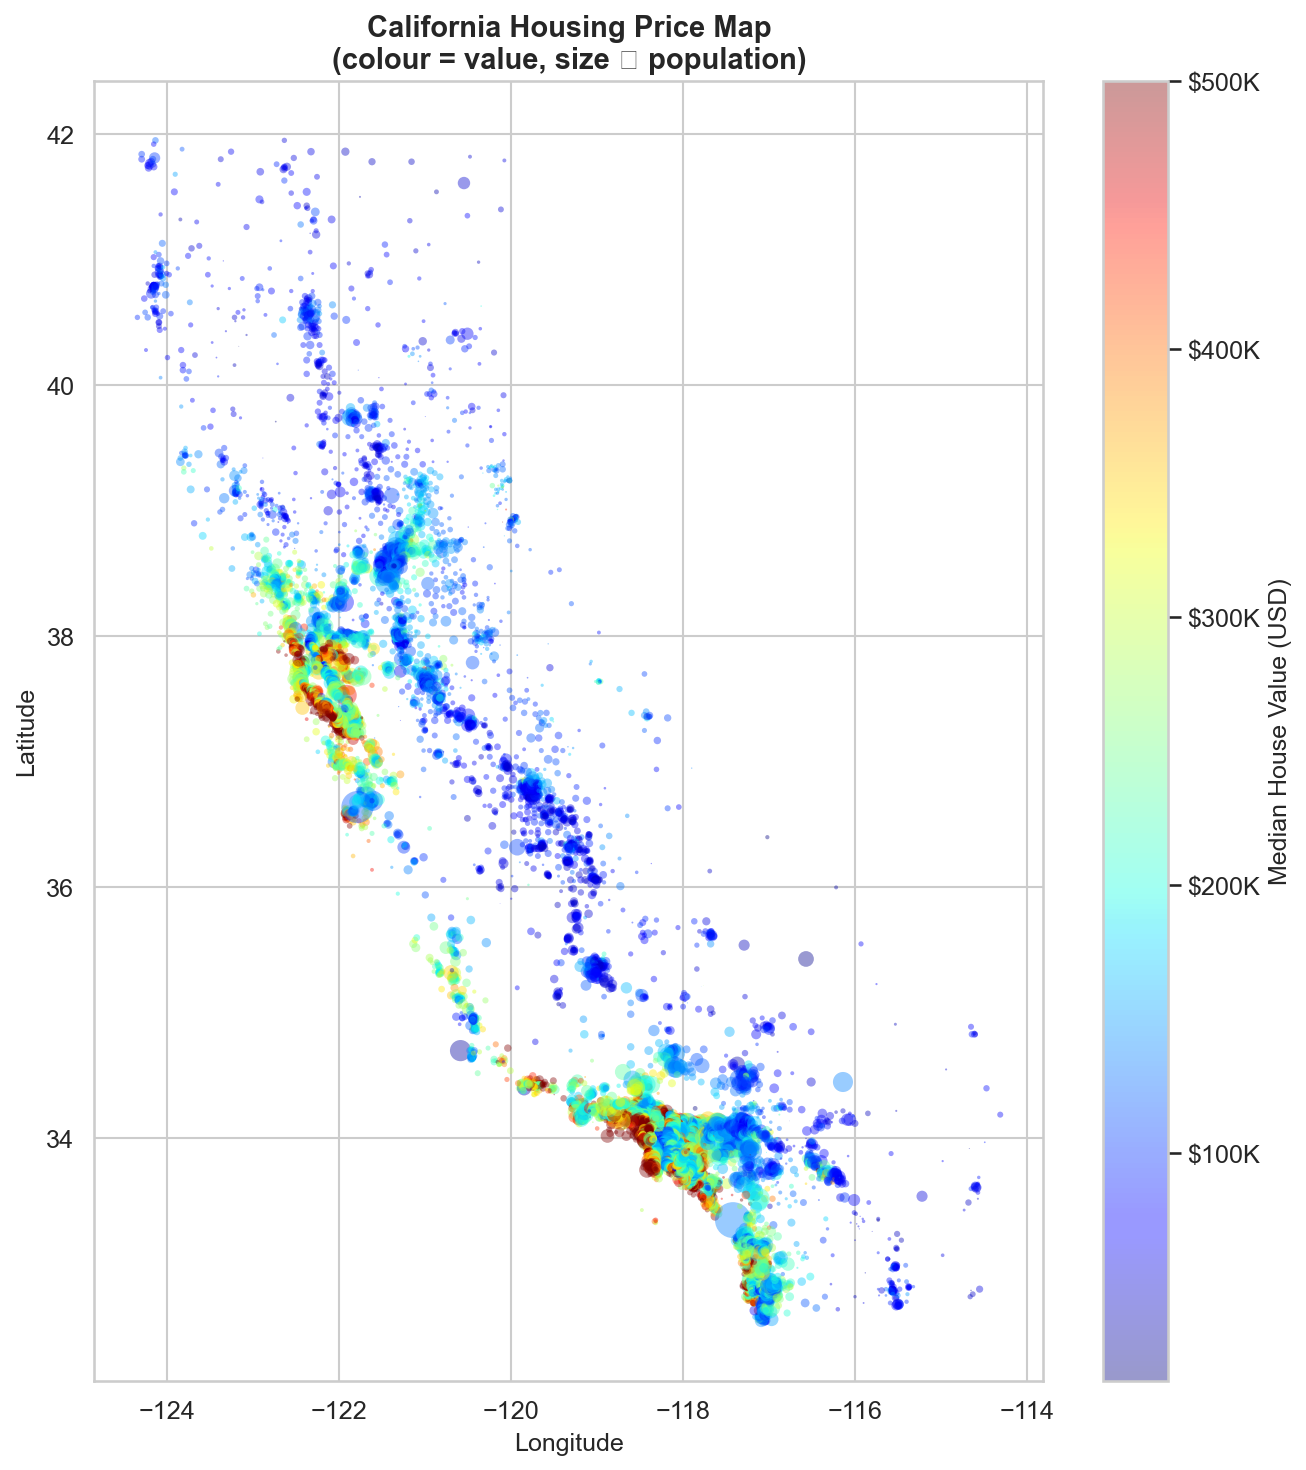

In [26]:
fig, ax = plt.subplots(figsize=(9, 10))
sc = ax.scatter(
    df['longitude'], df['latitude'],
    c=df[TARGET], cmap='jet',
    s=df['population'] / 120, alpha=0.4,
    edgecolors='none'
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Median House Value (USD)', fontsize=LABEL_FS)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Longitude', fontsize=LABEL_FS)
ax.set_ylabel('Latitude',  fontsize=LABEL_FS)
ax.set_title('California Housing Price Map\n(colour = value, size ∝ population)',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_11_geo_price_map.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 12 — Outlier Analysis: Box Plots of All Numeric Features
**What it shows:** Side-by-side box plots (standardised) for all 8 numeric features.  
**Presentation use:** After StandardScaler, count-based features (`total_rooms`, `population`) still have extreme outlier whiskers — these become extreme input values for the MLP.

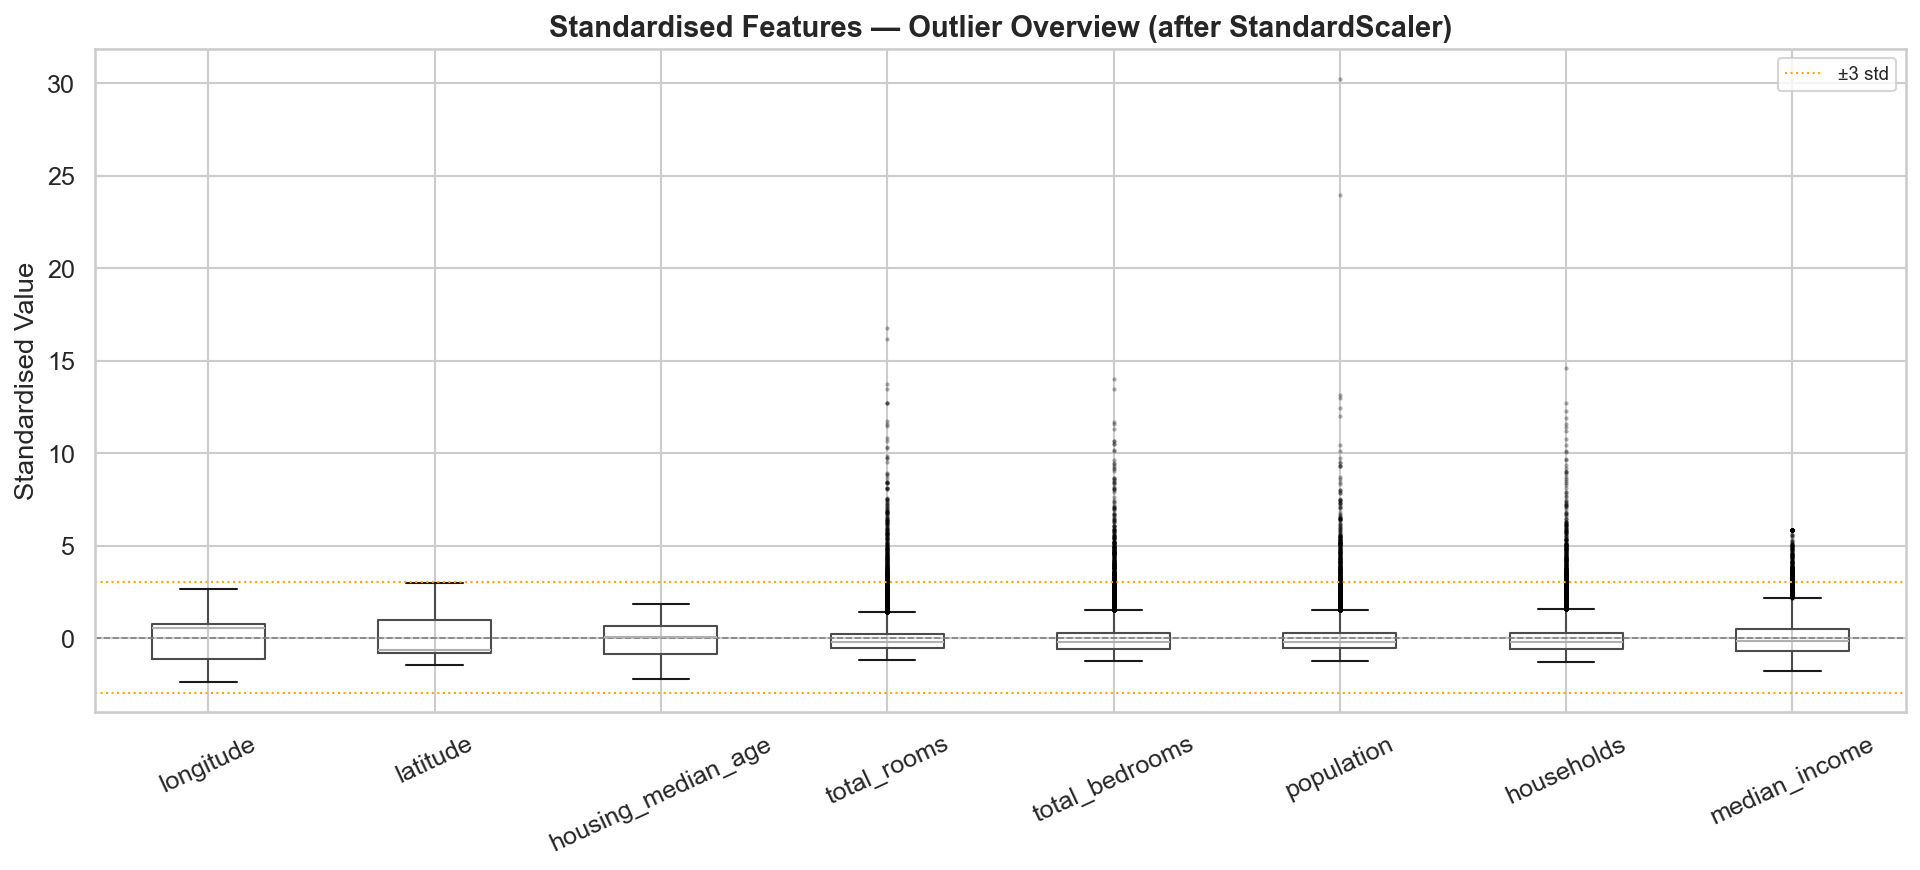

In [27]:
from sklearn.preprocessing import StandardScaler
X_sc = pd.DataFrame(StandardScaler().fit_transform(df[NUMERIC_FEATURES]),
                    columns=NUMERIC_FEATURES)

fig, ax = plt.subplots(figsize=(13, 6))
X_sc.boxplot(ax=ax, vert=True,
             flierprops=dict(marker='.', markersize=2, alpha=0.3, color='red'))
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axhline(3, color='orange', linewidth=1, linestyle=':', label='±3 std')
ax.axhline(-3, color='orange', linewidth=1, linestyle=':')
ax.set_title('Standardised Features — Outlier Overview (after StandardScaler)',
             fontsize=TITLE_FS, fontweight='bold')
ax.set_ylabel('Standardised Value')
ax.tick_params(axis='x', rotation=25)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_12_standardised_boxplots.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 13 — Train / Test Split: Distribution Comparison
**What it shows:** KDE of `median_income` and `median_house_value` in train vs test sets.  
**Presentation use:** Verifies that the 80/20 random split is representative — the distributions match closely, so test-set evaluation is fair.

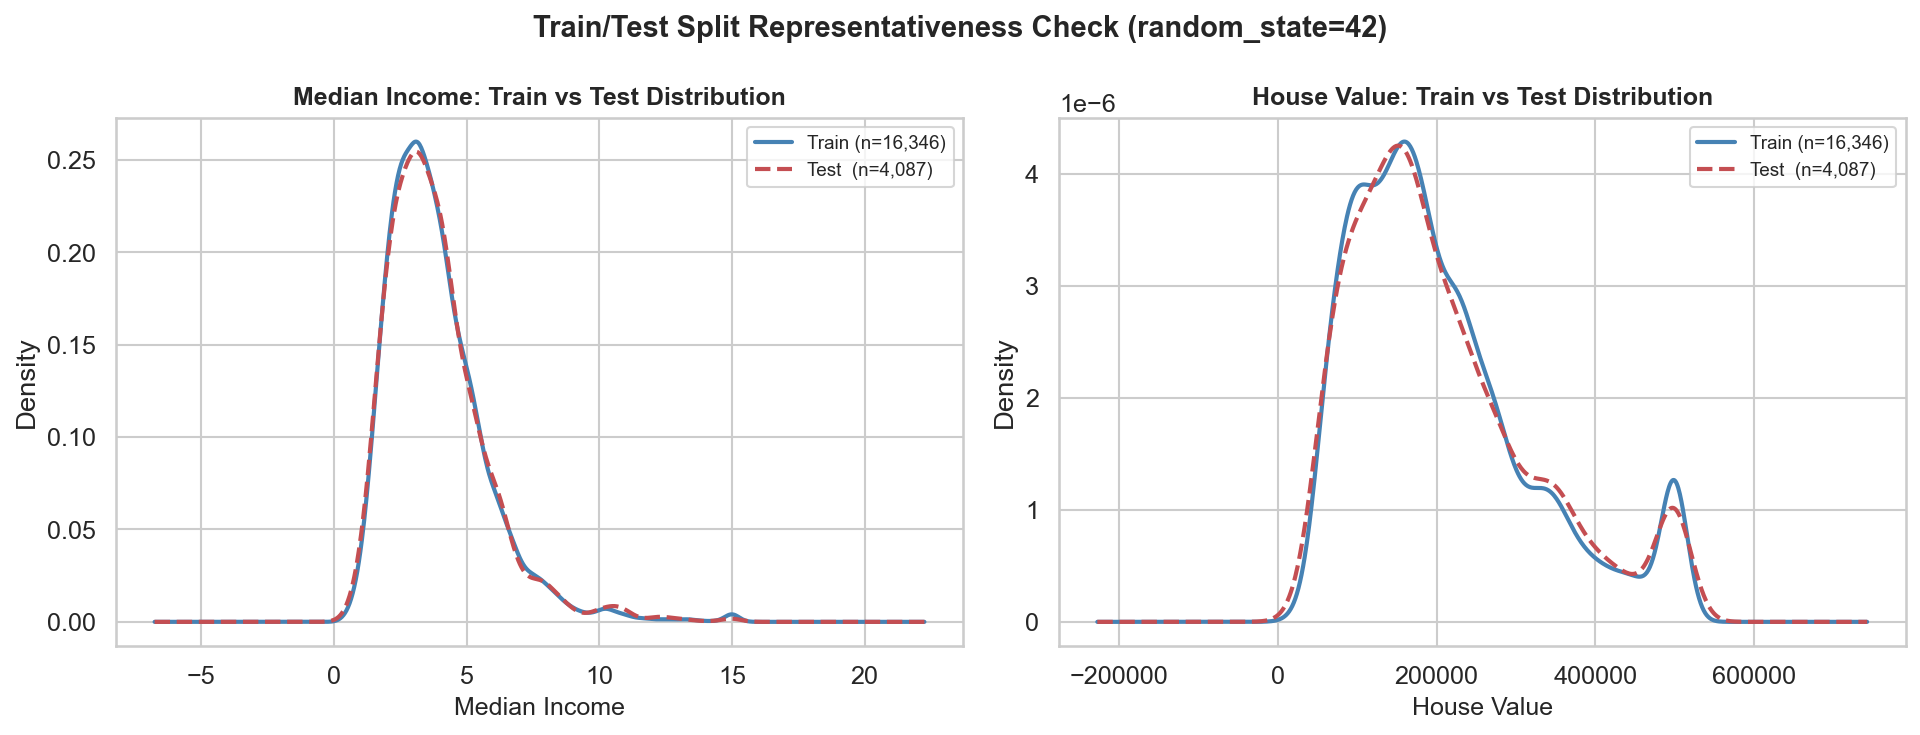

In [28]:
from sklearn.model_selection import train_test_split

df_enc = pd.get_dummies(df, columns=['ocean_proximity'], dtype=float)
X_all  = df_enc.drop(columns=[TARGET]).values
y_all  = df_enc[TARGET].values

_, _, y_tr, y_te, df_tr_idx, df_te_idx = train_test_split(
    X_all, y_all, range(len(df)), test_size=0.2, random_state=42
)

df_train_sub = df.iloc[list(df_tr_idx)]
df_test_sub  = df.iloc[list(df_te_idx)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, lbl in [
    (axes[0], 'median_income',    'Median Income'),
    (axes[1], TARGET, 'House Value')
]:
    df_train_sub[col].plot.kde(ax=ax, label=f'Train (n={len(df_train_sub):,})',
                               color='steelblue', linewidth=2)
    df_test_sub[col].plot.kde(ax=ax, label=f'Test  (n={len(df_test_sub):,})',
                              color='#C44E52', linewidth=2, linestyle='--')
    ax.set_xlabel(lbl, fontsize=LABEL_FS)
    ax.set_title(f'{lbl}: Train vs Test Distribution', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Train/Test Split Representativeness Check (random_state=42)',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot03_13_train_test_distributions.png', dpi=FIG_DPI)
plt.show()

---
## Summary — Notebook 03

| Plot | File | Key Takeaway for Presentation |
|------|------|-------------------------------|
| 1 | plot03_01_missing_values | Only `total_bedrooms` has NaN; 207 rows dropped (<1%) |
| 2 | plot03_02_target_distribution | Right-skewed target; ~4% of data hard-capped at $500K — a known model weakness |
| 3 | plot03_03_feature_distributions | Count features (rooms, population) are highly skewed → needs StandardScaler |
| 4 | plot03_04_scaler_effect | StandardScaler brings all features to equal scale |
| 5 | plot03_05_correlation_matrix | Strong multicollinearity among count features; income stands out |
| 6 | plot03_06_target_correlations | `median_income` r=0.69; `latitude` r=-0.14; location matters |
| 7 | plot03_07_feature_vs_target_scatter | $500K ceiling visible as horizontal band in every scatter |
| 8 | plot03_08_hexbin_income_value | Dense positive band; ceiling effects clearly visible |
| 9 | plot03_09_ocean_proximity | INLAND = 43% of data; ISLAND rare; coastal districts command premium |
| 10 | plot03_10_onehot_mean_values | Each one-hot category carries distinct price signal for MLP |
| 11 | plot03_11_geo_price_map | Bay Area and LA price clusters explain lat/lon feature importance |
| 12 | plot03_12_standardised_boxplots | Count features have extreme outliers even after scaling |
| 13 | plot03_13_train_test_distributions | Train/test distributions match well → fair evaluation |